[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4715/3478821164.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


Shape: (25, 5)
                   Category                   Metric  \
0           Company profile          Core businesses   
1  Latest operating results          Q2 2026 revenue   
2  Latest operating results  Q2 2026 Adjusted EBITDA   
3  Latest operating results   Q2 2026 free cash flow   
4         FY2025 financials                  Revenue   

                 Comcast Corporation (NASDAQ: CMCSA)  \
0  Connectivity and Platforms; NBCUniversal; Peac...   
1                       $29.94bn; down 1.2% reported   
2                        $8.9bn; down 13.4% reported   
3                                             $4.6bn   
4                                           $123.7bn   

                Warner Bros. Discovery (NASDAQ: WBD)  \
0  Streaming; Warner Bros. studios; HBO Max; disc...   
1                           $8.717bn; down 12% ex-FX   
2                            $1.879bn; down 6% ex-FX   
3                                              $572m   
4                              

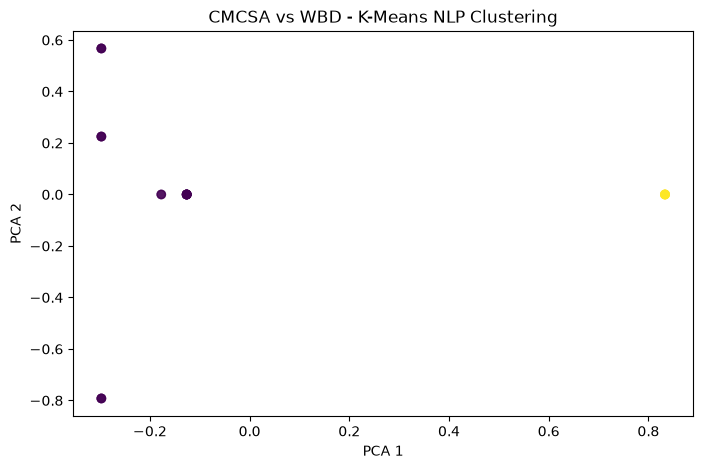


Cluster 0 keywords:
['scenario', 'financials', 'fy', 'fy financials', 'latest operating', 'operating results', 'latest', 'operating', 'results', 'capital']

Cluster 1 keywords:
['segments', 'view', 'latest', 'balance', 'balance sheet', 'capital', 'capital allocation', 'catalyst', 'company', 'company profile']

Saved: CMCSA_vs_WBD_Clustered.csv


In [1]:
# =========================================================
# CMCSA vs WBD - NLP + K-MEANS
# =========================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

# 1. Load dataset
df = pd.read_csv("CMCSA_vs_WBD_Comparison.csv")

print("Shape:", df.shape)
print(df.head())
print(df.columns)

# 2. Find text column
text_col = df.select_dtypes(include="object").columns[0]
print("Text column:", text_col)

# 3. Clean text
stop_words = set(stopwords.words("english"))

def clean_text(x):
    x = str(x).lower()
    x = re.sub(r'[^a-z\s]', '', x)
    return " ".join(
        word for word in x.split()
        if word not in stop_words
    )

df["clean_text"] = df[text_col].fillna("").apply(clean_text)

# 4. NLP - TF-IDF
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF shape:", X.shape)

# 5. K-Means
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

print("\nCluster counts:")
print(df["Cluster"].value_counts())

# 6. PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    alpha=0.7
)

plt.title("CMCSA vs WBD - K-Means NLP Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 7. Important words in each cluster
terms = tfidf.get_feature_names_out()

for cluster in range(2):
    center = kmeans.cluster_centers_[cluster]
    top_words = center.argsort()[-10:][::-1]

    print(f"\nCluster {cluster} keywords:")
    print([terms[i] for i in top_words])

# 8. Save results
df.to_csv(
    "CMCSA_vs_WBD_Clustered.csv",
    index=False
)

print("\nSaved: CMCSA_vs_WBD_Clustered.csv")